# Постобработка для отображения в [0,1]

In [11]:
import mitsuba as mi
mi.set_variant('llvm_ad_rgb')

scene = mi.load_dict(mi.cornell_box())
params = mi.traverse(scene)
params['sensor.film.size'] = (1000, 1000)
params.update()

img = mi.render(scene, spp=64)

In [12]:
img_bitmap = mi.Bitmap(img)
print(img_bitmap)

Bitmap[
  pixel_format = rgb,
  component_format = float32,
  size = [1000, 1000],
  srgb_gamma = 0,
  struct = Struct<12>[
    float32 R; // @0, premultiplied alpha
    float32 G; // @4, premultiplied alpha
    float32 B; // @8, premultiplied alpha
  ],
  data = [ 11.4 MiB of image data ]
]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..18.709522].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.49697].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.055..3.5200207].


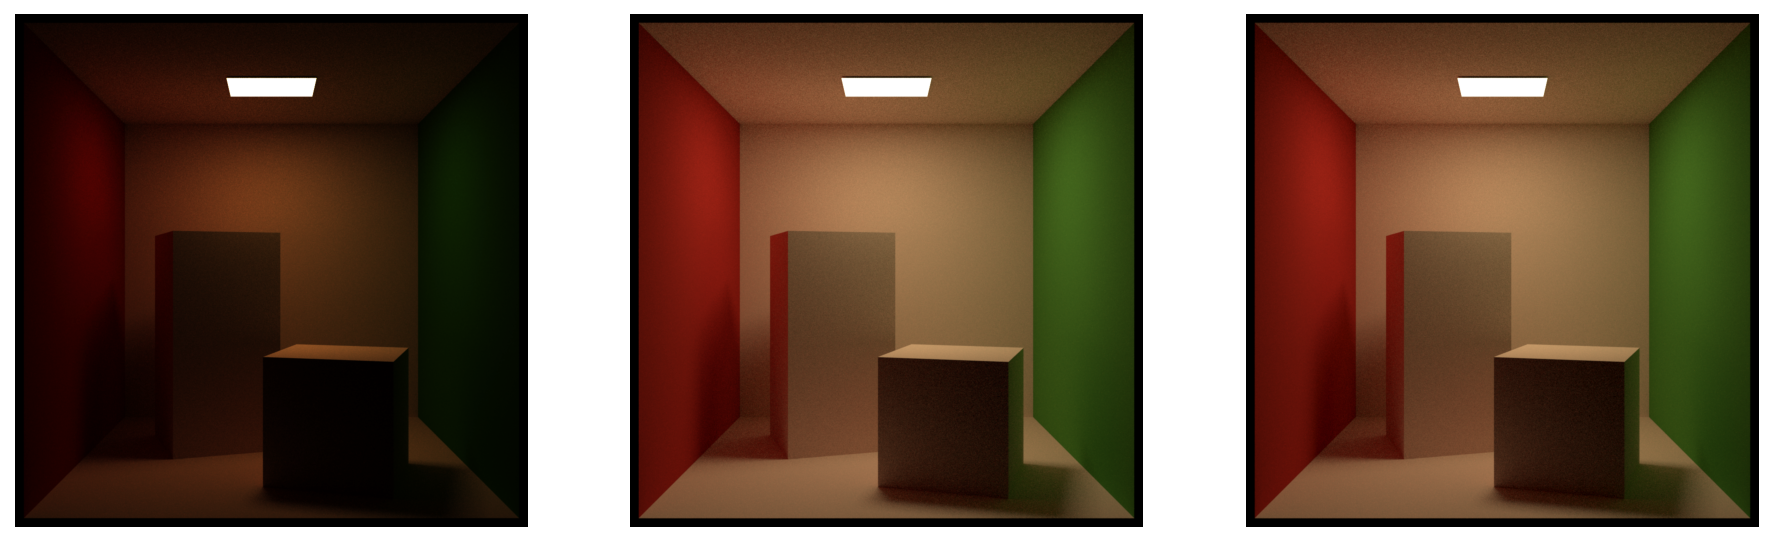

In [13]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), dpi=150)

ax[0].imshow(np.array(img_bitmap, dtype=np.float32))
ax[0].axis('off')

cnv_bitmap = img_bitmap.convert(
    srgb_gamma=True
)

ax[1].imshow(np.array(cnv_bitmap, dtype=np.float32))
ax[1].axis('off')

ax[2].imshow(1.055 * np.array(img_bitmap, dtype=np.float32)**(1/2.4) - 0.055)
ax[2].axis('off');

In [8]:
mi.variants()

['scalar_rgb',
 'scalar_spectral',
 'scalar_spectral_polarized',
 'llvm_ad_rgb',
 'llvm_ad_mono',
 'llvm_ad_mono_polarized',
 'llvm_ad_spectral',
 'llvm_ad_spectral_polarized',
 'cuda_ad_rgb',
 'cuda_ad_mono',
 'cuda_ad_mono_polarized',
 'cuda_ad_spectral',
 'cuda_ad_spectral_polarized']

# Разработка сцен

In [14]:
import mitsuba as mi

In [70]:
scene = mi.load_file('xml-scenes/scene.xml')
params = mi.traverse(scene)
#params.
#print(params)

In [71]:
#scene = mi.load_file('xml-scenes/scene.xml')
#img = mi.render(scene, spp=256)
#mi.Bitmap(img)

In [75]:
import mitsuba as mi
import numpy as np
from scipy.spatial.transform import Rotation as R_scipy

mi.set_variant('scalar_rgb')

def decompose_transform(transform):
    matrix = np.array(transform.matrix)
    
    # Translation
    translation = matrix[0:3, 3]
    
    # Linear part 3x3
    linear_part = matrix[0:3, 0:3]
    
    # Scale
    scale = np.array([
        np.linalg.norm(linear_part[:, 0]),
        np.linalg.norm(linear_part[:, 1]),
        np.linalg.norm(linear_part[:, 2])
    ])
    
    # Rotation matrix
    rotation_matrix = np.zeros((3, 3))
    for i in range(3):
        if scale[i] > 1e-8:
            rotation_matrix[:, i] = linear_part[:, i] / scale[i]
        else:
            rotation_matrix[:, i] = linear_part[:, i]
    
    # Handle negative scale
    if np.linalg.det(rotation_matrix) < 0:
        scale[0] *= -1
        rotation_matrix[:, 0] *= -1
    
    # Euler angles
    rot_scipy = R_scipy.from_matrix(rotation_matrix)
    euler_angles = rot_scipy.as_euler('xyz', degrees=True)
    
    return translation, scale, euler_angles

In [32]:
cb = mi.cornell_box()

In [86]:
objects = ['sensor', 'light', 'floor', 'ceiling', 'back', 'green-wall', 'red-wall', 'small-box', 'large-box']
mat = {}

for obj in objects:
    mat = cb[obj]['to_world']
    tr, sc, an = decompose_transform(mat)
    print(f'\nobj: {obj}')
    print(f'{'transform':<10} : {tr}')
    print(f'{'scale':<10} : {sc}')
    print(f'{'rotate':<10} : {an}')


obj: sensor
transform  : [0.  0.  3.9]
scale      : [1.         0.99999994 0.99999994]
rotate     : [180.   0. 180.]

obj: light
transform  : [0.   0.99 0.01]
scale      : [0.22999999 0.19       0.19      ]
rotate     : [90.0000025  0.         0.       ]

obj: floor
transform  : [ 0. -1.  0.]
scale      : [0.99999994 1.         1.        ]
rotate     : [-90.0000025   0.          0.       ]

obj: ceiling
transform  : [0. 1. 0.]
scale      : [0.99999994 1.         1.        ]
rotate     : [90.0000025  0.         0.       ]

obj: back
transform  : [ 0.  0. -1.]
scale      : [1. 1. 1.]
rotate     : [0. 0. 0.]

obj: green-wall
transform  : [1. 0. 0.]
scale      : [1.         0.99999994 1.        ]
rotate     : [  0.        -89.9999975   0.       ]

obj: red-wall
transform  : [-1.  0.  0.]
scale      : [1.         0.99999994 1.        ]
rotate     : [-0.        89.9999975  0.       ]

obj: small-box
transform  : [ 0.335 -0.7    0.38 ]
scale      : [0.30000004 0.3        0.30000004]
rotate  

/tmp/ipykernel_3529/3252428097.py:38: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  euler_angles = rot_scipy.as_euler('xyz', degrees=True)


In [87]:
cb

{'type': 'scene',
 'integrator': {'type': 'path', 'max_depth': 8},
 'sensor': {'type': 'perspective',
  'fov_axis': 'smaller',
  'near_clip': 0.001,
  'far_clip': 100.0,
  'focus_distance': 1000,
  'fov': 39.3077,
  'to_world': Transform[
    matrix=[[-1, 0, 0, 0],
            [0, 1, 0, 0],
            [0, 0, -1, 3.9],
            [0, 0, 0, 1]],
    inverse_transpose=[[-1, 0, 0, 0],
                       [0, 1, 0, 0],
                       [0, 0, -1, 0],
                       [0, 0, 3.9, 1]]
  ],
  'sampler': {'type': 'independent', 'sample_count': 64},
  'film': {'type': 'hdrfilm',
   'width': 256,
   'height': 256,
   'rfilter': {'type': 'gaussian'},
   'pixel_format': 'rgb',
   'component_format': 'float32'}},
 'white': {'type': 'diffuse',
  'reflectance': {'type': 'rgb', 'value': [0.885809, 0.698859, 0.666422]}},
 'green': {'type': 'diffuse',
  'reflectance': {'type': 'rgb', 'value': [0.105421, 0.37798, 0.076425]}},
 'red': {'type': 'diffuse',
  'reflectance': {'type': 'rgb', 'v